### Import statements

In [48]:
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.formula.api import ols
import pandas as pd
from datetime import datetime

## Sensor calibration

### Subcritical sensor calibration curve

b0 = 36.867167582476284
b1 = 2.2729171352478246


Text(0, 0.5, 'Water level (cm)')

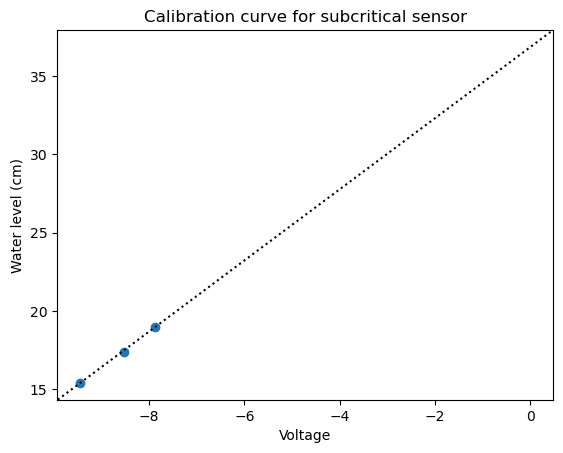

In [49]:
# calibration data
sub_voltage = np.array([-9.4592, -8.5297, -7.8816])
sub_height = np.array([15.4, 17.4, 19])                     # cm
sub_df = pd.DataFrame({'Voltage':sub_voltage, 'Height':sub_height})

# linear fit
sub_calibration = ols('Height ~ Voltage', data=sub_df).fit()
sub_b0, sub_b1 = sub_calibration.params
print(f'b0 = {sub_b0}')
print(f'b1 = {sub_b1}')

# plot
plt.scatter(sub_voltage, sub_height)
plt.axline(xy1=(0,sub_b0), slope=sub_b1, color='black', linestyle=':')
plt.title('Calibration curve for subcritical sensor')
plt.xlabel('Voltage')
plt.ylabel('Water level (cm)')

### Supercritical sensor calibration curve

b0 = 28.6137223023922
b1 = 2.2998132138163467


Text(0, 0.5, 'Water level (cm)')

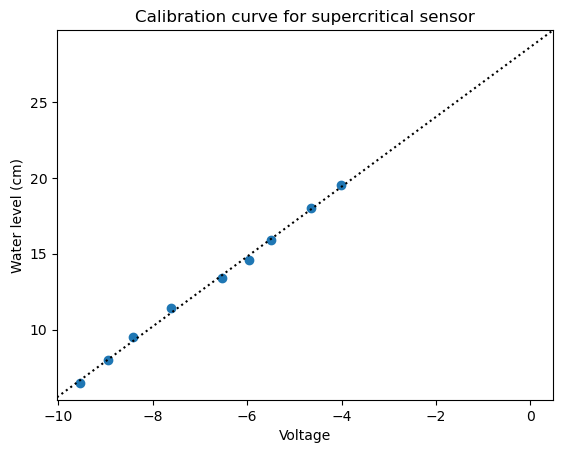

In [50]:
# calibration data
super_voltage = np.array([-9.5491, -8.9420, -8.4136, -7.6184, -6.5391, -5.9702, -5.4983, -4.6409, -4.0175])
super_height = np.array([6.5, 8, 9.5, 11.4, 13.4, 14.6, 15.9, 18, 19.5])    # cm
super_df = pd.DataFrame({'Voltage':super_voltage, 'Height':super_height})

# linear fit
super_calibration = ols('Height ~ Voltage', data=super_df).fit()
super_b0, super_b1 = super_calibration.params
print(f'b0 = {super_b0}')
print(f'b1 = {super_b1}')

# plot
plt.scatter(super_voltage, super_height)
plt.axline(xy1=(0,super_b0), slope=super_b1, color='black', linestyle=':')
plt.title('Calibration curve for supercritical sensor')
plt.xlabel('Voltage')
plt.ylabel('Water level (cm)')

### Head tank sensor calibration curve

b0 = 50.484996799317166
b1 = 2.0198975781500037


Text(0, 0.5, 'Water level (cm)')

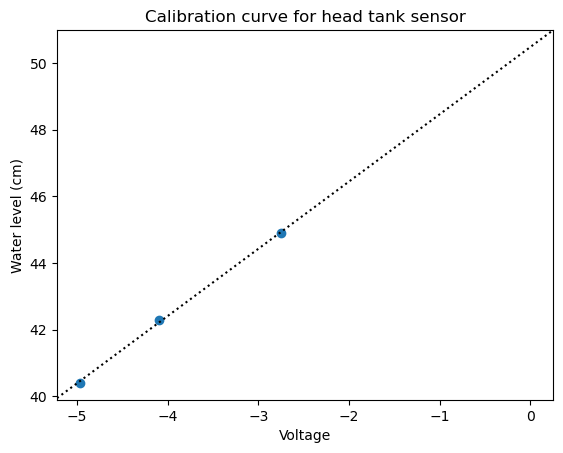

In [51]:
# calibration data
head_voltage = np.array([-2.75, -4.09, -4.97])
head_distance = np.array([9.6, 12.2, 14.1])    # cm, sensor distance from water surface
head_df = pd.DataFrame({'Voltage':head_voltage, 'Distance':head_distance})

# convert distance from water surface to water level
dist_bottom_to_vernier = 143.4 # cm
vernier_reading = 0 # ADD VERNIER READING TO WHATEVER OLS SPITS OUT FOR AN ACCURATE INTERCEPT
#vernier_reading = 0.452*30.48 # ft to cm THIS WILL BE MODIFIED THROUGHOUT EXPERIMENT SO WATCH THIS WHEN PROCESSING DATA
length_vernier = 88.9 # cm

head_df['Height'] = dist_bottom_to_vernier - (length_vernier - vernier_reading) - head_df['Distance']

# linear fit
head_calibration = ols('Height ~ Voltage', data=head_df).fit()
head_b0, head_b1 = head_calibration.params
print(f'b0 = {head_b0}')
print(f'b1 = {head_b1}')

# plot
plt.scatter(head_df['Voltage'], head_df['Height'])
plt.axline(xy1=(0,head_b0), slope=head_b1, color='black', linestyle=':')
plt.title('Calibration curve for head tank sensor')
plt.xlabel('Voltage')
plt.ylabel('Water level (cm)')

#### CALCULATIONS DURING EXPERIMENT

In [52]:
voltage_subcritical = -1.9178
voltage_head = -2.8499

height_subcritical = sub_b0 + sub_b1 * voltage_subcritical
height_head = head_b0 + head_b1 * voltage_head

head_diff = height_head - height_subcritical
print(f'Subcritical height is {height_subcritical:0.2f} cm')
print(f'Head tank height is {height_head:0.2f} cm')
print(f'Head difference is {head_diff:0.2f} cm')

Subcritical height is 32.51 cm
Head tank height is 44.73 cm
Head difference is 12.22 cm


## Load data

### Read venturi meter csv file

In [53]:
venturi_file = '11-14-2025.csv'
venturi_df = pd.read_csv(venturi_file, sep=';')
venturi_df = venturi_df.drop(['State PV', 'State SV', 'State TV', 'QV', 'State QV', 'Current [mA] ', 'State Current'], axis=1)
venturi_df['PV [in H2O] '] = venturi_df['PV [in H2O] '].str.replace(',', '.')
venturi_df['SV [C] '] = venturi_df['SV [C] '].str.replace(',', '.')
venturi_df['TV'] = venturi_df['TV'].str.replace(',', '.')
venturi_df['Time stamp'] = pd.to_datetime(venturi_df['Time stamp'], format='%d.%m.%Y %H:%M:%S')

display(venturi_df)

,Time stamp,PV [in H2O],SV [C],TV
0,2025-11-14 10:06:41,0.025753041729331,21.03759765625,0.000103012156614568
1,2025-11-14 10:06:43,0.0252222381532192,21.03759765625,0.000100888966699131
2,2025-11-14 10:06:45,0.0246667675673962,21.0379333496094,9.8667063866742E-05
3,2025-11-14 10:06:47,0.0253644995391369,21.0379333496094,0.000101458026620094
4,2025-11-14 10:06:50,0.0248334482312202,21.0379333496094,9.93338180705905E-05
...,...,...,...,...
1813,2025-11-14 11:22:02,0.0298138335347176,21.1524047851563,0.000119058189739008
1814,2025-11-14 11:22:05,0.0367372632026672,21.1527709960938,0.000146949096233584
1815,2025-11-14 11:22:07,0.0440103933215141,21.1526184082031,0.000176989691681229
1816,2025-11-14 11:22:10,0.0277848057448864,21.1527709960938,0.000111139219370671


In [54]:
venturi_file_2 = '11-14-2025-a.csv'
venturi_df_2 = pd.read_csv(venturi_file_2, sep=';')
venturi_df_2 = venturi_df_2.drop(['State PV', 'State SV', 'State TV', 'QV', 'State QV', 'Current [mA] ', 'State Current'], axis=1)
venturi_df_2['PV [in H2O] '] = venturi_df_2['PV [in H2O] '].str.replace(',', '.')
venturi_df_2['SV [C] '] = venturi_df_2['SV [C] '].str.replace(',', '.')
venturi_df_2['TV'] = venturi_df_2['TV'].str.replace(',', '.')

display(venturi_df_2)

,Time stamp,PV [in H2O],SV [C],TV
0,14.11.2025 11:41:13,0.0238170213997364,21.1109619140625,9.52681075432338E-05
1,14.11.2025 11:41:16,0.0258504804223776,21.1111450195313,0.00010340192966396
2,14.11.2025 11:41:18,0.0270843952894211,21.1107788085938,0.000108337582787499
3,14.11.2025 11:41:21,0.0284676589071751,21.1104125976563,0.000113870650238823
4,14.11.2025 11:41:23,0.0267552454024553,21.1102294921875,0.000107020998257212
...,...,...,...,...
633,14.11.2025 12:06:16,0.0506160147488117,21.2000732421875,0.000202464056201279
634,14.11.2025 12:06:18,0.0521851107478142,21.2002258300781,0.000208740486414172
635,14.11.2025 12:06:20,0.0298577435314655,21.2002258300781,0.000119430980703328
636,14.11.2025 12:06:23,0.0179873052984476,21.2006225585938,7.19492381904274E-05


### Read ADV data file

In [55]:
from datetime import datetime

adv_file = 'hre_adv20251114101722.dat'
adv_data = pd.read_csv(adv_file, sep='\s+', header=None)
start_time = datetime(2025, 11, 7, 10, 25, 48)
end_time = datetime(2025, 11, 7, 11, 50, 5)

time_diff = (end_time - start_time).total_seconds()

freq = 20 # Hz

display(adv_data)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,118,11,0.150,-0.901,-0.045,-0.025,129,148,45,141,21.4,21.1,15.0,23.0,86,91,72,89
1,119,11,0.079,-0.924,-0.009,0.000,117,139,49,137,20.5,20.6,15.7,22.7,93,94,86,96
2,120,11,0.110,-0.919,-0.014,-0.001,122,136,44,123,20.9,20.4,14.8,21.8,95,95,81,96
3,121,11,0.111,-0.946,-0.018,-0.003,121,130,49,113,20.8,20.0,15.7,21.1,93,92,84,93
4,122,11,0.049,-0.972,-0.036,-0.024,120,141,49,132,20.8,20.7,15.7,22.4,89,91,81,93
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78958,79081,11,0.003,-0.009,-0.685,-0.677,7,8,5,6,-3.9,-4.2,-4.1,-4.4,55,48,100,90
78959,79082,11,0.894,0.873,-0.445,-0.460,7,8,4,6,-3.9,-4.2,-6.0,-4.4,55,33,100,100
78960,79083,11,0.002,0.009,-0.685,-0.682,7,8,5,6,-3.9,-4.2,-4.1,-4.4,55,48,100,100
78961,79084,11,-0.930,-0.024,-0.454,-0.690,6,8,4,6,-5.3,-4.2,-6.0,-4.4,79,37,100,100


### Read height sensor csv files

In [56]:
import glob

csv_files = sorted(glob.glob('*sensor_data.csv'))
dfs = []

for file_name in csv_files:
    try:
        df = pd.read_csv(file_name)
        dfs.append(df)
        print(f"Successfully read: {file_name}")
    except Exception as e:
        print(f"Error reading {file_name}: {e}")

V_ai0 = np.empty(len(csv_files))
V_ai1 = np.empty(len(csv_files))
V_ai2 = np.empty(len(csv_files))

for i, df in enumerate(dfs):
    V_ai0[i] = df['V_ai0'].mean()
    V_ai1[i] = df['V_ai1'].mean()
    V_ai2[i] = df['V_ai2'].mean()

sensor_data = pd.DataFrame({'V_ai0': V_ai0, 'V_ai1': V_ai1, 'V_ai2': V_ai2}) # note that trial indices are one less than the ones I wrote in the notebook
sensor_data['Vernier'] = 0.125

Successfully read: 2025-11-14_10-15-56_sensor_data.csv
Successfully read: 2025-11-14_10-19-52_sensor_data.csv
Successfully read: 2025-11-14_11-18-24_sensor_data.csv
Successfully read: 2025-11-14_11-44-08_sensor_data.csv
Successfully read: 2025-11-14_11-48-19_sensor_data.csv
Successfully read: 2025-11-14_11-50-57_sensor_data.csv
Successfully read: 2025-11-14_11-54-12_sensor_data.csv
Successfully read: 2025-11-14_11-56-51_sensor_data.csv
Successfully read: 2025-11-14_11-59-10_sensor_data.csv
Successfully read: 2025-11-14_12-03-01_sensor_data.csv


### Convert voltages to water heights

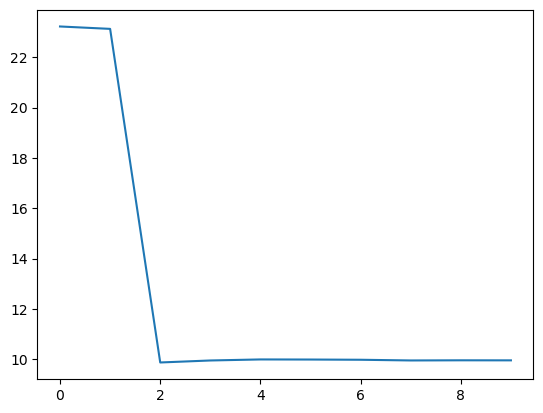

In [57]:
sensor_data['Supercritical Height (cm)'] = super_b0 + super_b1 * sensor_data['V_ai1'] # DOUBLE CHECK IF YOU MATCHED THESE CORRECTLY

plt.plot(sensor_data['Supercritical Height (cm)'])


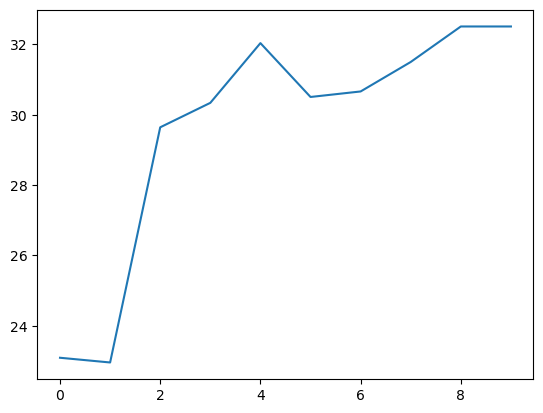

In [58]:
sensor_data['Subcritical Height (cm)'] = sub_b0 + sub_b1 * sensor_data['V_ai0']

plt.plot(sensor_data['Subcritical Height (cm)'])

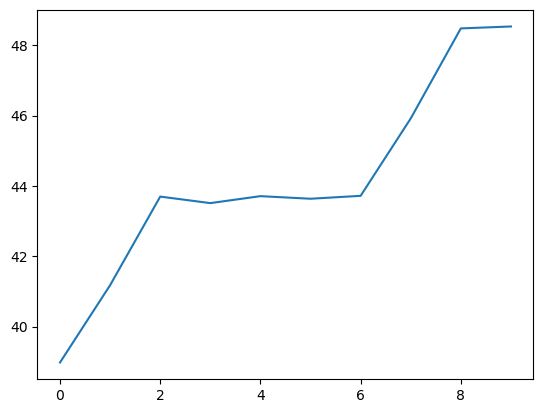

In [59]:
sensor_data['Head Tank Height (cm)'] = head_b0 + sensor_data['Vernier']*30.48 + head_b1 * sensor_data['V_ai2']

plt.plot(sensor_data['Head Tank Height (cm)'])

### Plot the curves together

Text(0, 0.5, 'Water level (cm)')

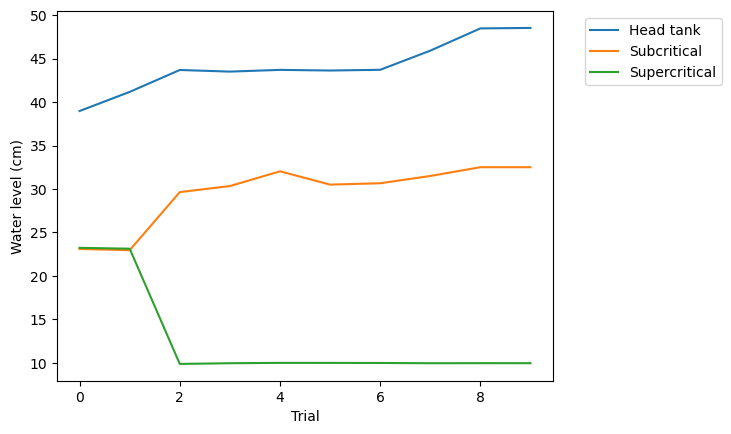

In [60]:
plt.plot(sensor_data['Head Tank Height (cm)'])
plt.plot(sensor_data['Subcritical Height (cm)'])
plt.plot(sensor_data['Supercritical Height (cm)'])


plt.legend(['Head tank', 'Subcritical', 'Supercritical'], bbox_to_anchor=(1.05, 1))
plt.xlabel('Trial')
plt.ylabel('Water level (cm)')

## Stage discharge curve

### Calculate discharge

In [61]:
end_time = datetime(2025,11,14,10,19,52)
start_time = datetime(2025,11,14,10,19,32)

trial1_venturi_df = venturi_df[(venturi_df['Time stamp'] <= end_time) & (venturi_df['Time stamp'] >= start_time)]
display(trial1_venturi_df)

PV = np.mean(pd.to_numeric(trial1_venturi_df['PV [in H2O] ']).values)
discharge = 0.1753*(PV/75.36)**(1/2)
print(discharge)

,Time stamp,PV [in H2O],SV [C],TV
313,2025-11-14 10:19:34,53.6619911193848,21.0674438476563,0.214648008346558
314,2025-11-14 10:19:36,53.3599815368652,21.0674438476563,0.213439956307411
315,2025-11-14 10:19:39,52.2103996276855,21.0676574707031,0.208841666579247
316,2025-11-14 10:19:41,53.0315093994141,21.0676574707031,0.212126046419144
317,2025-11-14 10:19:44,52.7077713012695,21.0684204101563,0.210831120610237
318,2025-11-14 10:19:46,51.9172821044922,21.0684204101563,0.207669138908386
319,2025-11-14 10:19:49,52.9442176818848,21.0684204101563,0.211776897311211
320,2025-11-14 10:19:51,53.403076171875,21.0684204101563,0.213612347841263


0.14687838742691642


In [62]:
# sensor_data['Delta P'] = np.array([76, 84, 93, 103, 112.5]) # from venturi meter

# sensor_data['Q (m3/s)'] = 0.1753*(sensor_data['Delta P']/75.36)**(1/2)

### Calculate head difference

In [63]:
sensor_data['Head diff (cm)'] = sensor_data['Head Tank Height (cm)'] - sensor_data['Subcritical Height (cm)']
display(sensor_data)

,V_ai0,V_ai1,V_ai2,Vernier,Supercritical Height (cm),Subcritical Height (cm),Head Tank Height (cm),Head diff (cm)
0,-6.060159,-2.342622,-7.583966,0.125,23.226129,23.092929,38.976163,15.883234
1,-6.119158,-2.384034,-6.494833,0.125,23.130890,22.958828,41.176100,18.217273
2,-3.178454,-8.150850,-5.246668,0.125,9.868290,29.642806,43.697265,14.054460
3,-2.872641,-8.116326,-5.338620,0.125,9.947689,30.337893,43.511532,13.173638
4,-2.125741,-8.098339,-5.240483,0.125,9.989056,32.035535,43.709758,11.674223
5,-2.799218,-8.100018,-5.276951,0.125,9.985193,30.504777,43.636096,13.131319
6,-2.730214,-8.103872,-5.235863,0.125,9.976331,30.661617,43.719089,13.057471
7,-2.361582,-8.115921,-4.145733,0.125,9.948619,31.499486,45.921041,14.421554
8,-1.917714,-8.113287,-2.877072,0.125,9.954678,32.508363,48.483607,15.975243
9,-1.917777,-8.114199,-2.849882,0.125,9.952580,32.508219,48.538527,16.030308


### Graph stage vs discharge 

In [64]:
import seaborn as sns

In [65]:
print(f'Discharge (m3/s):{discharge:0.2f}')
print(f'Head difference (cm): {sensor_data['Head diff (cm)'][1]:0.2f}')

scaled_discharge = discharge*(3.05**3)
scaled_head_diff = sensor_data['Head diff (cm)'][1]*3.05

print(f'Scaled discharge (m3/s): {scaled_discharge:0.2f}')
print(f'Scaled head difference (m): {scaled_head_diff/100:0.2f}')

Discharge (m3/s):0.15
Head difference (cm): 18.22
Scaled discharge (m3/s): 4.17
Scaled head difference (m): 0.56


In [66]:
# sns.scatterplot(x='Head diff (cm)', y='Q (m3/s)', hue=np.arange(0, len(sensor_data)), data=sensor_data, palette='viridis')
# plt.plot(sensor_data['Head diff (cm)'], sensor_data['Q (m3/s)'], color='black', linestyle=':')
# #sns.lineplot(x='Head diff (cm)', y='Delta P', data=sensor_data)
# plt.xlabel('Head difference (cm)')
# plt.ylabel('Flow rate (cubic m/s)')
# plt.legend(title='Trial number')
# plt.title('Stage discharge curve')

# display(sensor_data)

## Calculate Re, Fr, head loss, etc

In [67]:
def calc_head_loss(sub, super):
    return ((sub - super)**3)/(4*sub*super)

sensor_data['Head loss (cm)'] = calc_head_loss(sensor_data['Subcritical Height (cm)'], sensor_data['Supercritical Height (cm)'])

display(sensor_data)

,V_ai0,V_ai1,V_ai2,Vernier,Supercritical Height (cm),Subcritical Height (cm),Head Tank Height (cm),Head diff (cm),Head loss (cm)
0,-6.060159,-2.342622,-7.583966,0.125,23.226129,23.092929,38.976163,15.883234,-0.000001
1,-6.119158,-2.384034,-6.494833,0.125,23.130890,22.958828,41.176100,18.217273,-0.000002
2,-3.178454,-8.150850,-5.246668,0.125,9.868290,29.642806,43.697265,14.054460,6.608400
3,-2.872641,-8.116326,-5.338620,0.125,9.947689,30.337893,43.511532,13.173638,7.022587
4,-2.125741,-8.098339,-5.240483,0.125,9.989056,32.035535,43.709758,11.674223,8.371462
5,-2.799218,-8.100018,-5.276951,0.125,9.985193,30.504777,43.636096,13.131319,7.091226
6,-2.730214,-8.103872,-5.235863,0.125,9.976331,30.661617,43.719089,13.057471,7.233671
7,-2.361582,-8.115921,-4.145733,0.125,9.948619,31.499486,45.921041,14.421554,7.984873
8,-1.917714,-8.113287,-2.877072,0.125,9.954678,32.508363,48.483607,15.975243,8.862786
9,-1.917777,-8.114199,-2.849882,0.125,9.952580,32.508219,48.538527,16.030308,8.866997
